<a href="https://colab.research.google.com/github/cyycyy77/ML-DL_study/blob/dev/ML_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

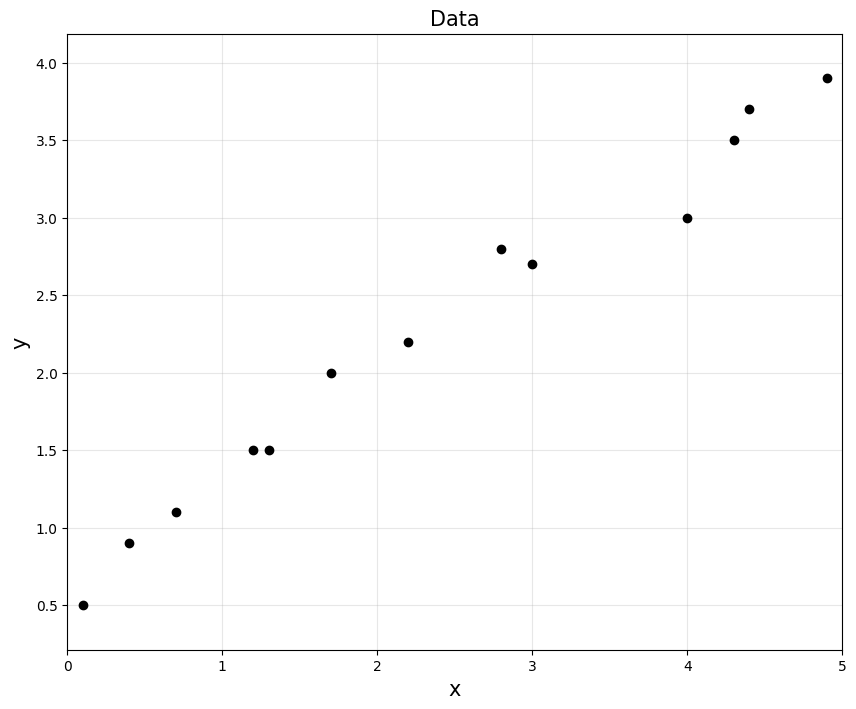

In [ ]:
# solve using linear algebra
from typing_extensions import FrozenSet
x = np.array([0.1, 0.4, 0.7, 1.2, 1.3, 1.7, 2.2, 2.8, 3.0, 4.0, 4.3, 4.4, 4.9]).reshape(-1, 1)
y = np.array([0.5, 0.9, 1.1, 1.5, 1.5, 2.0, 2.2, 2.8, 2.7, 3.0, 3.5, 3.7, 3.9]).reshape(-1, 1)

plt.figure (figsize=(10,8))
plt.plot(x, y, 'ko')
plt.title('Data', fontsize=15)
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.axis('equal')
plt.grid(alpha=0.3)
plt.xlim([0, 5])
plt.show()

In [ ]:
m = y.shape[0]
A = np.hstack([x**0, x])
A = np.asmatrix(A)

# \theta = (A^T *A)^{-1} A^T *y
theta = (A.T*A).I*A.T*y

print('theta :n', theta)

theta :n [[0.65306531]
 [0.67129519]]


<function matplotlib.pyplot.show(close=None, block=None)>

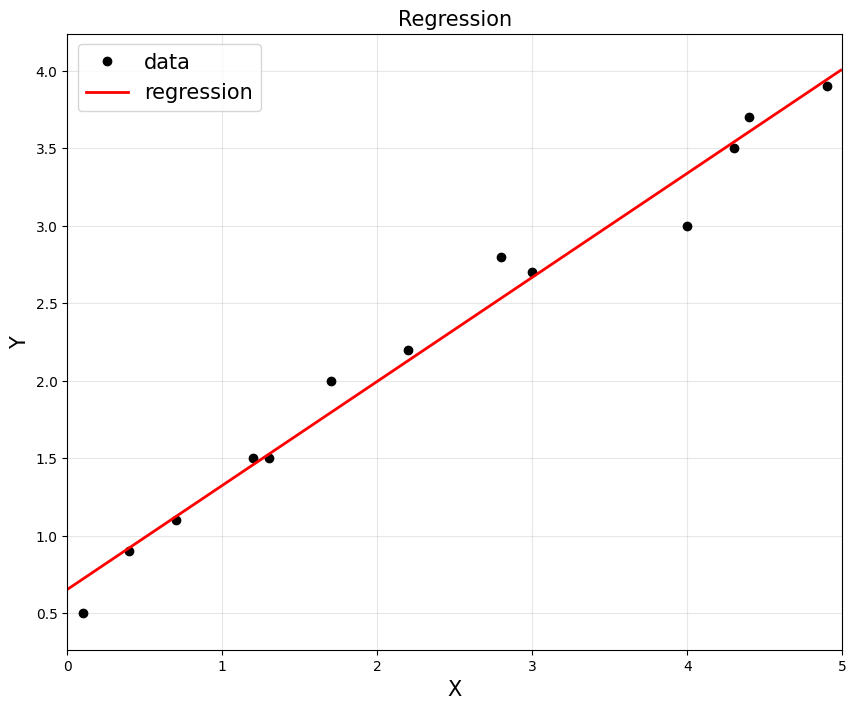

In [ ]:
plt.figure(figsize=(10,8))
plt.title('Regression', fontsize=15)
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)
plt.plot(x, y, 'ko', label="data")

# straight line
xp = np.arange(0, 5, 0.01).reshape(-1,1)
yp = theta[0,0] + theta[1,0]*xp

plt.plot(xp, yp, 'r', linewidth=2, label="regression")
plt.legend(fontsize=15)
plt.axis('equal')
plt.grid(alpha=0.3)
plt.xlim([0, 5])
plt.show

**same contnet using Skit-Learn**

In [ ]:
from sklearn import linear_model

In [ ]:
# 객체를 생성(선형 회귀를 위한)하고, 연산을 수행
reg = linear_model.LinearRegression()
reg.fit(x,y)

LinearRegression()

In [ ]:
reg.coef_
# same as theta[1,0]

array([[0.67129519]])

In [ ]:
reg.intercept_
# same as theta[0.0]

array([0.65306531])

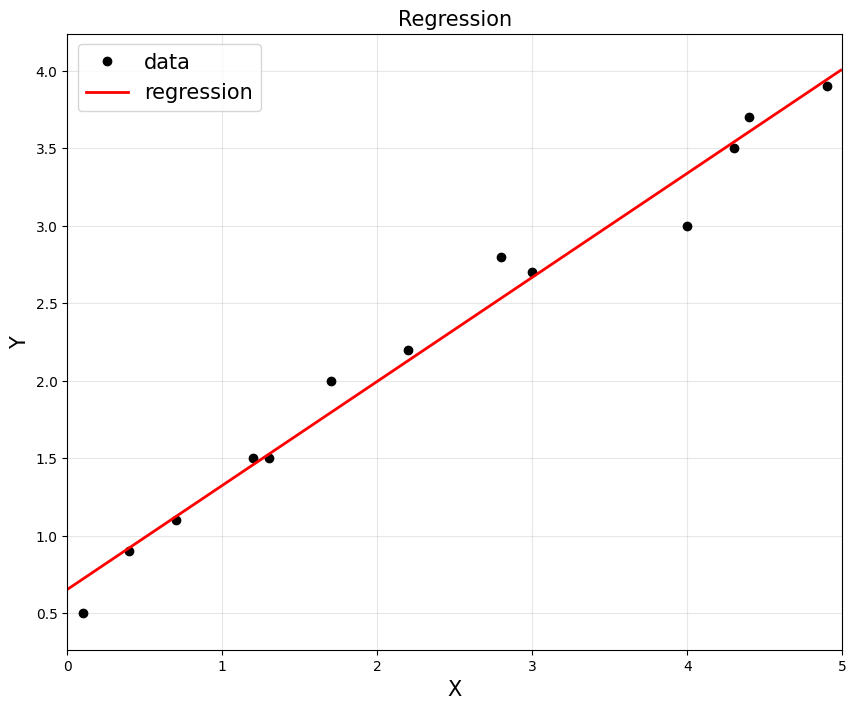

In [ ]:
plt.figure(figsize=(10,8))
plt.title("Regression", fontsize=15)
plt.xlabel("X", fontsize=15)
plt.ylabel("Y", fontsize=15)
plt.plot(x, y, "ko", label="data")

# straight line
plt.plot(xp, reg.predict(xp), "r", linewidth=2, label="regression")
plt.legend(fontsize=15)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.xlim([0, 5])
plt.show()

---
# **L1 norm vs L2 norm**

In [ ]:
# add outlier
x = np.vstack([x, np.array([0.5, 3.8]).reshape(-1,1)])
y = np.vstack([y, np.array([3.9, 0.3]).reshape(-1,1)])

A = np.hstack([x**0, x])
A = np.asmatrix(A)

import cvxpy as cvx

**norm 1**

In [ ]:
# norm 1
theta1 = cvx.Variable((2,1))
obj1 = cvx.Minimize(cvx.norm(A*theta1-y, 1))
prob1 = cvx.Problem(obj1).solve()

/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 3 times so far.

  warnings.warn(msg, UserWarning)


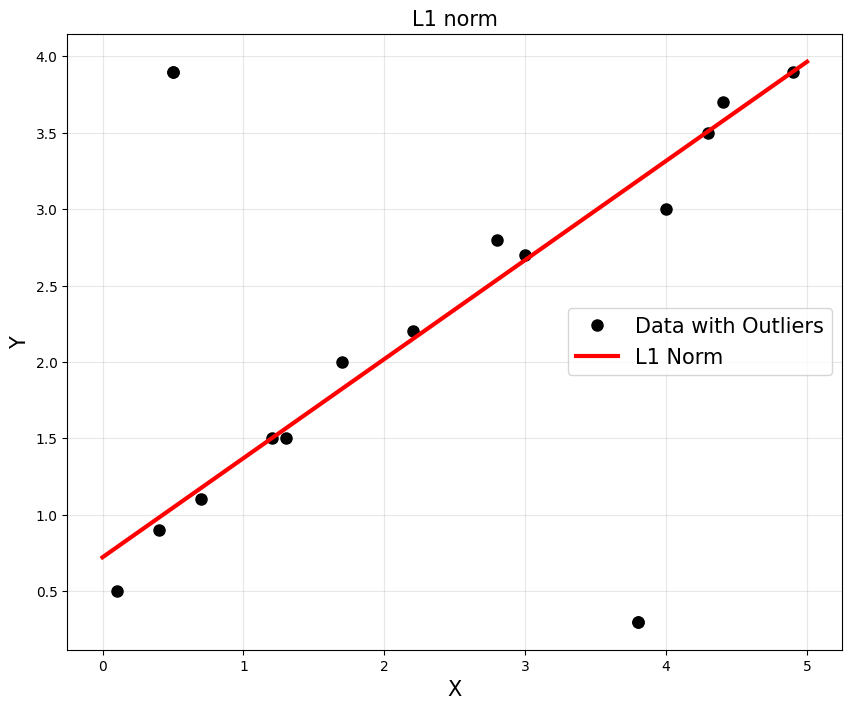

In [ ]:
plt.figure(figsize=(10, 8))
plt.title("L1 norm", fontsize=15)
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)

plt.plot(x, y, 'ko', markersize=8, label='Data with Outliers')

xp = np.linspace(0, 5, 100)

yp1 = theta1.value[0,0] + theta1.value[1,0] * xp
plt.plot(xp, yp1, 'r', linewidth=3, label='L1 Norm')
plt.legend(fontsize=15)
plt.grid(alpha=0.3)
plt.show()

**norm 2**

In [ ]:
# norm 1
theta2 = cvx.Variable((2,1))
obj2 = cvx.Minimize(cvx.norm(A*theta2-y, 2))
prob2 = cvx.Problem(obj2).solve()

/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 5 times so far.

  warnings.warn(msg, UserWarning)


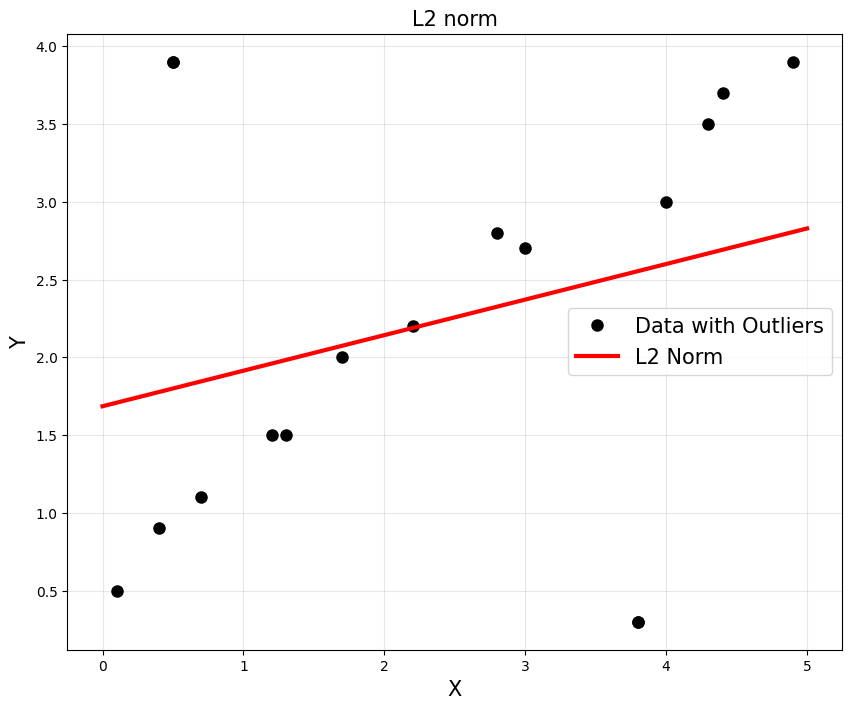

In [ ]:
plt.figure(figsize=(10, 8))
plt.title("L2 norm", fontsize=15)
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)

plt.plot(x, y, 'ko', markersize=8, label='Data with Outliers')

xp = np.linspace(0, 5, 100)

yp2 = theta2.value[0,0] + theta2.value[1,0] * xp
plt.plot(xp, yp2, 'r', linewidth=3, label='L2 Norm')
plt.legend(fontsize=15)
plt.grid(alpha=0.3)
plt.show()

---
# **Multivate Linear Regression**







In [ ]:
n = 200
x1 = np.random.randn(n, 1)
x2 = np.random.randn(n, 1)
noise = 0.5*np.random.randn(n, 1);

y = 2 + 1*x1 + 3*x2 + noise

In [ ]:
A = np.hstack([np.ones((n, 1)), x1, x2])
A = np.asmatrix(A)
theta = (A.T*A).I*A.T*y

X1, X2 = np.meshgrid(np.arange(np.min(x1), np.max(x1), 0.5),
                     np.arange(np.min(x2), np.max(x2), 0.5))
YP = theta[0,0] + theta[1,0]*X1 + theta[2,0]*X2

---
# **Polynomial Regression**







In [ ]:
n = 100
x = -5 + 15*np.random.rand(n,1)
noise = 10*np.random.rand(n,1)
y = 10 + 1*x + 2*x**2 +noise

In [ ]:
A = np.hstack([x**0, x, x**2])
A = np.asmatrix(A)

theta = (A.T*A).I*A.T*y
print("theta:\n", theta)

theta:
 [[15.52006118]
 [ 1.15436814]
 [ 1.9768481 ]]


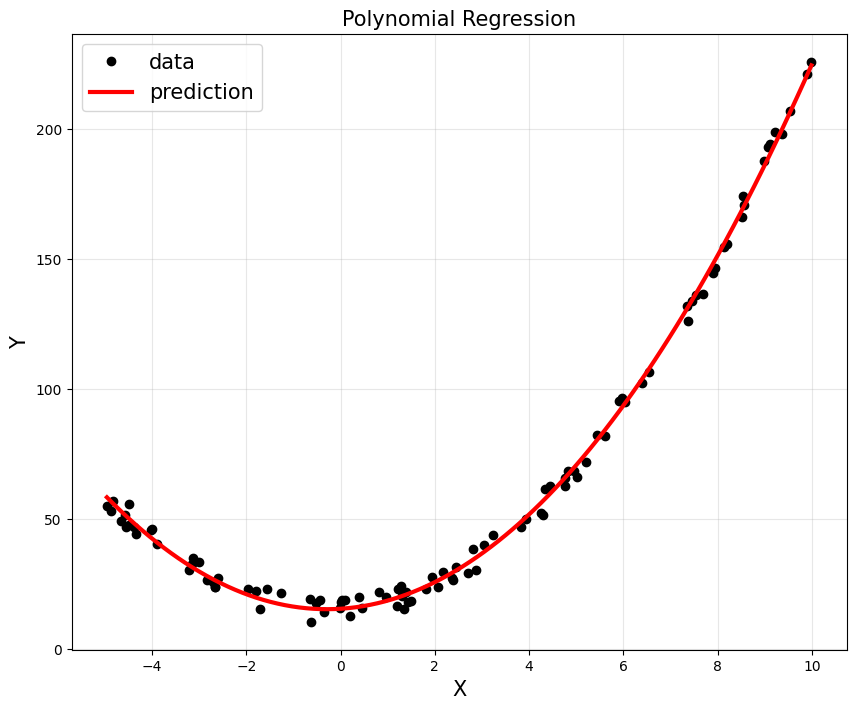

In [ ]:
plt.figure(figsize=(10, 8))
plt.title('Polynomial Regression', fontsize=15)
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)

# (1) 원래 데이터 점 찍기
plt.plot(x, y, 'ko', label="data")

# x좌표들을 생성
xp = np.linspace(np.min(x), np.max(x), 100).reshape(-1, 1)

# y = theta0 + theta1*x + theta2*x^2
yp = theta[0,0] + theta[1,0]*xp + theta[2,0]*xp**2

plt.plot(xp, yp, 'r', linewidth=3, label="prediction")

plt.legend(fontsize=15)
plt.grid(alpha=0.3)
plt.show()

---
# **Overfitting**

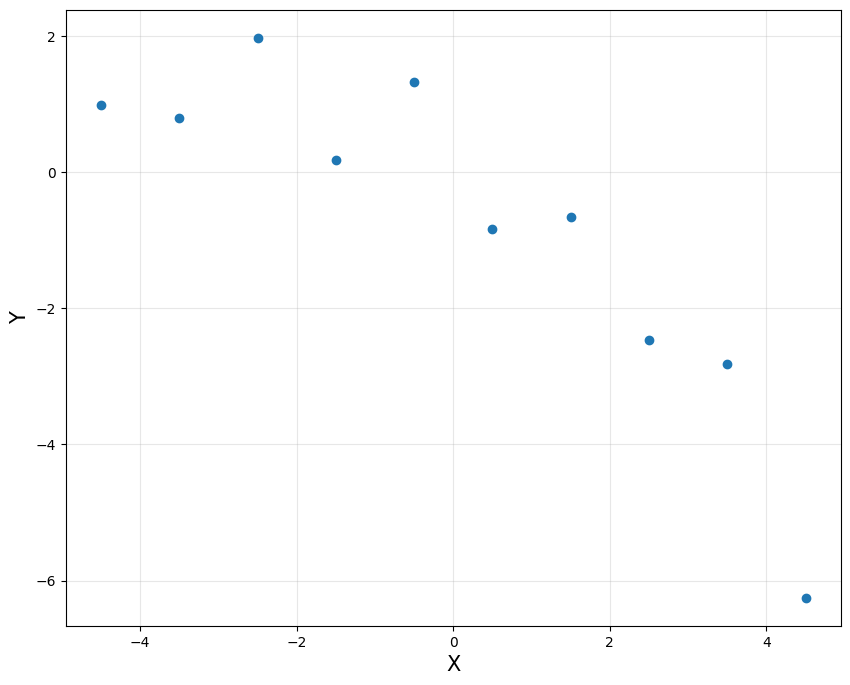

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 10 data points
n = 10
x = np.linspace(-4.5, 4.5, 10).reshape(-1, 1)
y = np.array([0.9819, 0.7973, 1.9737, 0.1838, 1.3180,
              -0.8361, -0.6591, -2.4701, -2.8122, -6.2512]).reshape(-1, 1)

plt.figure(figsize=(10, 8))
plt.plot(x, y, 'o', label = 'Data')
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)
plt.grid(alpha=0.3)
plt.show()

[[ 0.33669062]
 [-0.71070424]
 [-0.13504129]]


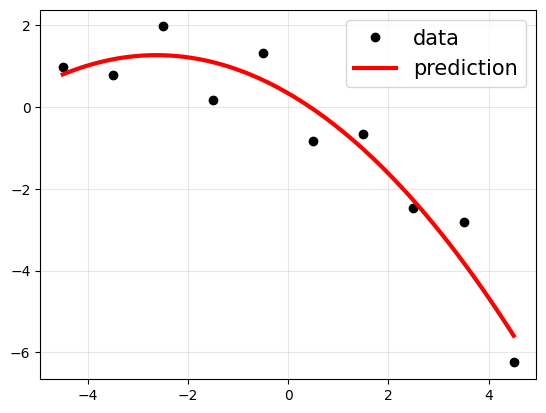

In [ ]:
A = np.hstack([x**0, x, x**2])
A = np.asmatrix(A)

theta = (A.T*A).I*A.T*y
# print(theta)

# data
plt.plot(x, y, 'ko', label="data")

# x predic
xp = np.linspace(np.min(x), np.max(x), 100).reshape(-1, 1)

# y = theta0 + theta1*x + theta2*x^2
# y predic
yp = theta[0,0] + theta[1,0]*xp + theta[2,0]*xp**2

plt.plot(xp, yp, 'r', linewidth=3, label="prediction")

plt.legend(fontsize=15)
plt.grid(alpha=0.3)
plt.show()

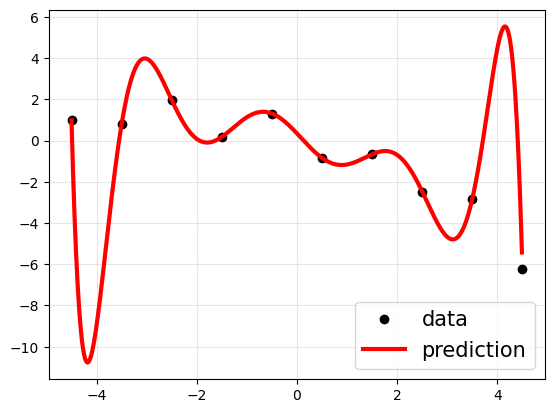

In [ ]:
A = np.hstack([x**i for i in range(10)])
A = np.asmatrix(A)

theta = (A.T*A).I*A.T*y
# print(theta)

# data
plt.plot(x, y, 'ko', label="data")

# # x predic
# xp = np.linspace(np.min(x), np.max(x), 100).reshape(-1, 1)

# x predic
xp = np.arange(-4.5, 4.5, 0.01).reshape(-1, 1)

# 학습 때와 똑같은 형태로 xp의 다항식 행렬(Poly_xp)을 만듭니다.
Poly_xp = np.hstack([xp**i for i in range(10)])
Poly_xp = np.asmatrix(Poly_xp)

# y = theta0 + theta1*x + theta2*x^2
# y predic
yp = Poly_xp*theta

plt.plot(xp, yp, 'r', linewidth=3, label="prediction")

plt.legend(fontsize=15)
plt.grid(alpha=0.3)
plt.show()

---
# **Regularization**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cvx
%matplotlib inline

# 10 data points
n = 10
x = np.linspace(-4.5, 4.5, 10).reshape(-1, 1)
y = np.array([0.9819, 0.7973, 1.9737, 0.1838, 1.3180,
              -0.8361, -0.6591, -2.4701, -2.8122, -6.2512]).reshape(-1, 1)

# 10 feature
deg = 10
A = np.hstack([x**i for i in range(deg+1)])
A = np.asmatrix(A)

# Regularization parameter(hyper-parameter)
gamma = 2.0

**L1 norm**

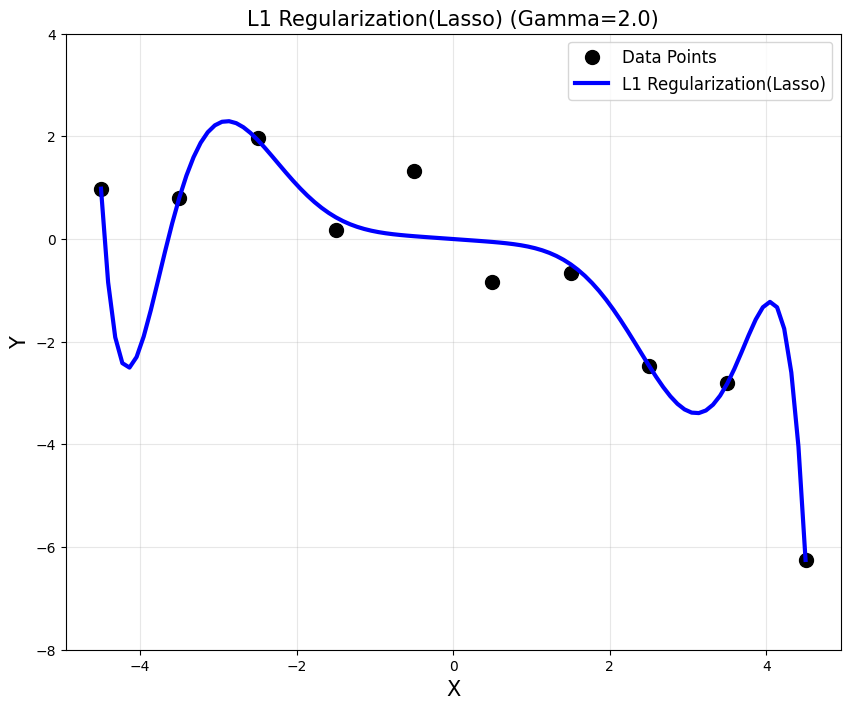

In [ ]:
theta_l1 = cvx.Variable((deg + 1, 1))
obj_l1 = cvx.Minimize(cvx.sum_squares(A @ theta_l1 - y) + gamma * cvx.norm(theta_l1, 1))
cvx.Problem(obj_l1).solve()

plt.figure(figsize=(10, 8))
plt.title(f'L1 Regularization(Lasso) (Gamma={gamma})', fontsize=15)
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)

# visualization
plt.plot(x, y, 'ko', markersize=10, label='Data Points')

xp = np.linspace(-4.5, 4.5, 100).reshape(-1, 1)


Ap = np.hstack([xp**i for i in range(deg + 1)])
Ap = np.asmatrix(Ap)

yp_l1 = Ap * theta_l1.value

plt.plot(xp, yp_l1, 'b-', linewidth=3, label='L1 Regularization(Lasso)')

plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.ylim([-8, 4]) # y축 범위 고정 (그래프 모양 비교를 위해)
plt.show()

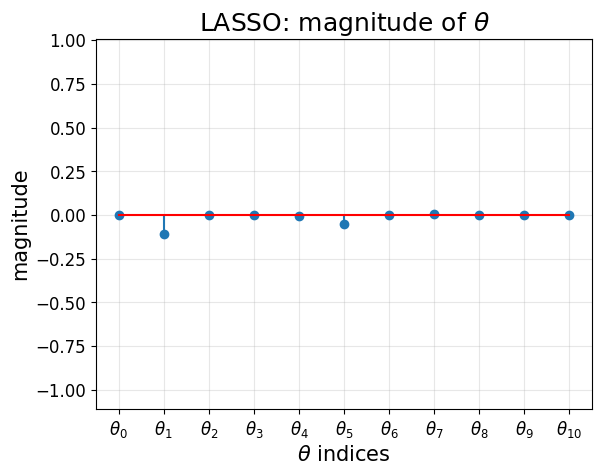

In [ ]:
theta_values = theta_l1.value.flatten()
indices = np.arange(len(theta_values))

stems = plt.stem(indices, theta_values, linefmt='C0-', markerfmt='C0o', basefmt='r-')

plt.title(r'LASSO: magnitude of $\theta$', fontsize=18) # LaTeX 문법 사용
plt.xlabel(r'$\theta$ indices', fontsize=15)
plt.ylabel('magnitude', fontsize=15)

# X축 눈금 설정 (0부터 9까지 정수로 표시)
plt.xticks(indices, [f'$\\theta_{{{i}}}$' for i in indices], fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, alpha=0.3)



plt.ylim([min(theta_values)-1, max(theta_values)+1]) # 여백 확보
plt.show()

**L2 norm**

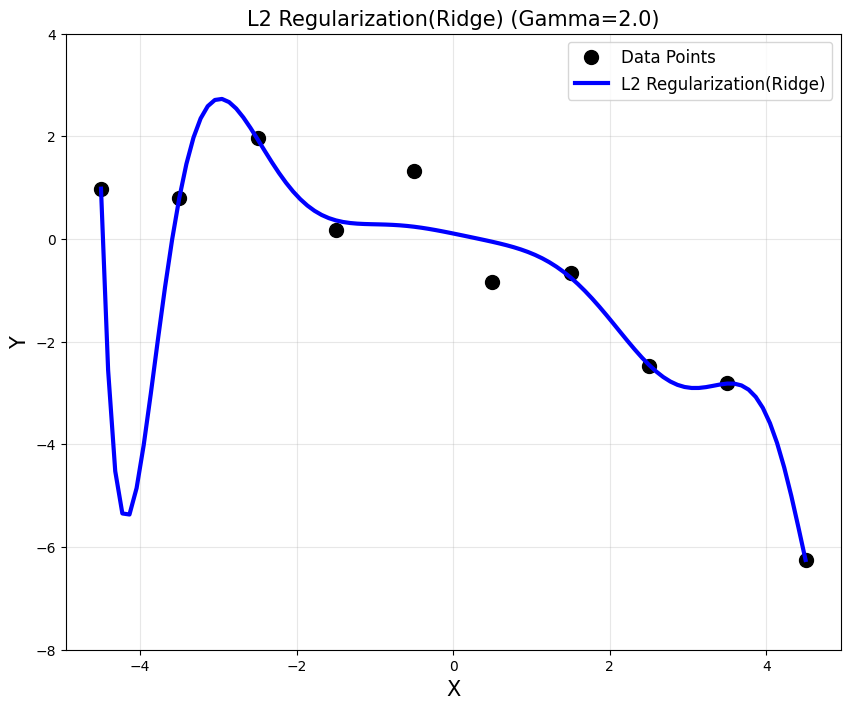

In [ ]:
theta_l2 = cvx.Variable((deg + 1, 1))
obj_l2 = cvx.Minimize(cvx.sum_squares(A @ theta_l2 - y) + gamma * cvx.sum_squares(theta_l2))
cvx.Problem(obj_l2).solve()

plt.figure(figsize=(10, 8))
plt.title(f'L2 Regularization(Ridge) (Gamma={gamma})', fontsize=15)
plt.xlabel('X', fontsize=15)
plt.ylabel('Y', fontsize=15)

# visualization
plt.plot(x, y, 'ko', markersize=10, label='Data Points')

xp = np.linspace(-4.5, 4.5, 100).reshape(-1, 1)


Ap = np.hstack([xp**i for i in range(deg + 1)])
Ap = np.asmatrix(Ap)

yp_l1 = Ap * theta_l2.value

plt.plot(xp, yp_l1, 'b-', linewidth=3, label='L2 Regularization(Ridge)')

plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.ylim([-8, 4]) # y축 범위 고정 (그래프 모양 비교를 위해)
plt.show()

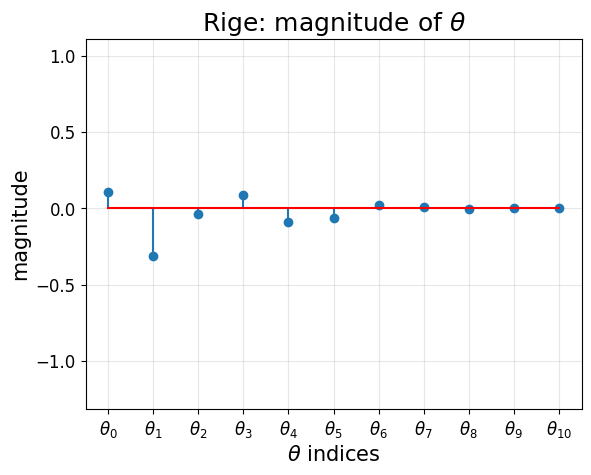

In [ ]:
theta_values = theta_l2.value.flatten()
indices = np.arange(len(theta_values))

stems = plt.stem(indices, theta_values, linefmt='C0-', markerfmt='C0o', basefmt='r-')

plt.title(r'Rige: magnitude of $\theta$', fontsize=18) # LaTeX 문법 사용
plt.xlabel(r'$\theta$ indices', fontsize=15)
plt.ylabel('magnitude', fontsize=15)

# X축 눈금 설정 (0부터 9까지 정수로 표시)
plt.xticks(indices, [f'$\\theta_{{{i}}}$' for i in indices], fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, alpha=0.3)


plt.ylim([min(theta_values)-1, max(theta_values)+1]) # 여백 확보
plt.show()

**결론**

In [ ]:
print("\n--- Weight Values Comparison ---")
print(f"{'Weight':<5} | {'L1 (Lasso)':>15} | {'L2 (Ridge)':>10}")
print("-" * 45)

for i in range(deg + 1):
    val_l1 = theta_l1.value[i, 0]
    val_l2 = theta_l2.value[i, 0]

    l1_str = "0.0000 (ZERO)" if abs(val_l1) < 1e-4 else f"{val_l1:.4f}"

    print(f"θ{i:<4} | {l1_str:>15} | {val_l2:10.4f}")


--- Weight Values Comparison ---
Weight |      L1 (Lasso) | L2 (Ridge)
---------------------------------------------
θ0    |   0.0000 (ZERO) |     0.1078
θ1    |         -0.1086 |    -0.3110
θ2    |   0.0000 (ZERO) |    -0.0384
θ3    |   0.0000 (ZERO) |     0.0854
θ4    |         -0.0069 |    -0.0884
θ5    |         -0.0523 |    -0.0650
θ6    |   0.0000 (ZERO) |     0.0250
θ7    |          0.0064 |     0.0072
θ8    |   0.0000 (ZERO) |    -0.0022
θ9    |         -0.0002 |    -0.0002
θ10   |   0.0000 (ZERO) |     0.0001
